In [69]:
import numpy as np
import matplotlib as plt
import scipy

# ================================================= Structural Functions =================================================

def compute_As(T,S):
    f = scipy.special.factorial(np.arange(S)).T
    i = np.arange(S)[:, None]
    j = np.arange(S)[None, :]
    jmi = j - i
    njmi = jmi.copy()
    njmi[njmi < 0] = 0
    j_fact = scipy.special.factorial(j)

    O = np.zeros((S, S))
    E = np.eye(S)*f
    U = np.eye(S)*1/f
    F = np.zeros((S, S))
    G = scipy.special.factorial(S+j)/scipy.special.factorial(S+j-i)*np.power(T,S+j-i)

    cond = i<=j
    F[cond] = np.where(cond,j_fact,0)[cond]/np.where(cond,scipy.special.factorial(j-i),0)[cond]*np.where(cond,np.power(T,njmi),0)[cond]


    I = np.broadcast_to(i+1, (S, S))
    J = np.broadcast_to(j+1, (S, S))
    K = np.arange(S + 1)[None, None, :]
    upper = S - np.maximum(I, J)
    mask_k = (K <= upper[..., None])
    n1 = I[..., None] + K
    n2 = (2*S - J[..., None] - K - 1)

    mask = (mask_k & (n1 >= 0) & (n1 <= S) & (n2 >= 0) & (n2 >= (S-1)))
    term = ((-1.0) ** K) * scipy.special.comb(S, n1, exact=False) * scipy.special.comb(n2, S-1, exact=False)
    v = np.sum(np.where(mask, term, 0.0), axis=-1)
    V = v/(j_fact*np.where(i%2, 1 ,-1)*np.power(T,S-J+I))


    n1 = I[..., None] - 1
    mask = (mask_k & (n1 >= 0) & (n1 <= S) & (n2 >= 0) & (n2 >= (S-1)))
    term = scipy.special.comb(S-K-1, n1, exact=False) * scipy.special.comb(n2, S-1, exact=False)
    w = np.sum(np.where(mask, term, 0.0), axis=-1)
    W = w/(j_fact*np.where((i+j)%2, -1 ,1)*np.power(T,S-J+I))

    Af = np.block([[E, O],[F,G]])
    Ab = np.block([[U, O],[V,W]])
    return Af,Ab

def compute_Q(T,N,S):
    i = (np.arange(N+1-S)+S)[:, None]
    j = (np.arange(N+1-S)+S)[None , :]
    temp = i+j-2*S+1
    Qbr = np.power(T,temp)/temp*scipy.special.factorial(i)/scipy.special.factorial(i-4)*scipy.special.factorial(j)/scipy.special.factorial(j-4)
    Q = np.zeros((N+1,N+1))
    Q[N-S+1:,N-S+1:] = Qbr
    return Q

def compute_dQdT(T,N,S):
    i = (np.arange(N+1-S)+S)[:, None]
    j = (np.arange(N+1-S)+S)[None , :]
    temp = i+j-2*S
    dQdTbr = np.power(T,temp)*scipy.special.factorial(i)/scipy.special.factorial(i-4)*scipy.special.factorial(j)/scipy.special.factorial(j-4)
    dQdT = np.zeros((N+1,N+1))
    dQdT[N-S+1:,N-S+1:] = dQdTbr
    return dQdT

def compute_AbDot(T,V,W,S):
    i = np.arange(S)[:, None]
    j = np.arange(S)[None, :]
    O = np.zeros((S, S))
    I = np.broadcast_to(i+1, (S, S))
    J = np.broadcast_to(j+1, (S, S))

    dV = V*(J-S-I)/T
    dW = W*(J-S-I)/T
    AbDot = np.block([[O, O],[dV,dW]])
    return AbDot

def BandedPLU(M, b, block_size):
    n = M.shape[0]
    lower = block_size
    upper = block_size
    ab = np.zeros((lower + upper + 1, n))

    for i in range(n):
        for j in range(max(0, i - lower), min(n, i + upper + 1)):
            ab[upper + i - j, j] = M[i, j]

    x = scipy.linalg.solve_banded((lower, upper), ab, b)
    return x




# ================================================= Algorithmic Functions =================================================

def init(Ts,checkpoints,S):
    N = 2 * S -1
    D = np.zeros((S-1,S))
    D[:,1:] = np.eye(S-1)
    M = len(Ts)
    dconst = np.zeros((S*len(checkpoints),1))
    for loop,i in enumerate(checkpoints):
        dconst[loop*S,0] = i
    Mm = np.zeros(((S-1)*(M-1),(S-1)*(M-1)))
    kappa = [np.array([x]+[0]*(S-1)) for x in checkpoints]

    return N,D,M,dconst,Mm,kappa

def construct_block_matries(T,N,S):
    Af,Ab = compute_As(T,S)
    Q = compute_Q(T,N,S)
    H = Ab.T@Q@Ab

    GAMA = H[:S,:S]
    LAMBDA = H[:S,S:]
    PHI = H[S:,:S]
    OMEGA = H[S:,S:]
    return Af,Ab,Q,H,GAMA,LAMBDA,PHI,OMEGA

def construct_lin_eq(Mm,GAMAs,LAMBDAs,PHIs,OMEGAs,kappa,M,D,S):
    b = np.zeros(((S-1)*(M-1)))
    for i in range(M-1):
        if i < M-2:
            x = np.block([[D@(OMEGAs[i]+GAMAs[i+1])@D.T, D@LAMBDAs[i+1]@D.T], [D@PHIs[i+1]@D.T, np.zeros(((S-1),(S-1)))]])
            Mm[(S-1)*i:(S-1)*(i+2) , (S-1)*i:(S-1)*(i+2)] = x

        b[(S-1)*i:(S-1)*(i+1)] = (-D@(PHIs[i]@kappa[i] + (OMEGAs[i]+GAMAs[i+1])@kappa[i+1] + LAMBDAs[i]@kappa[i+2]))

    Mm[-(S-1):,-(S-1):] = D@(OMEGAs[M-2]+GAMAs[M-1])@D.T
    return Mm,b[:,None]

def compute_dstar(Mm,b,dconst,M,S):
    dtildastar = BandedPLU(Mm,b,S-1)

    B = np.zeros(((M+1)*S,(M-1)*(S-1)))
    for i in range(M-1):
        B[(i+1)*S+1:(i+1)*S+1+S-1 , (S-1)*i:(S-1)*(i+1)] = np.eye(S-1)

    P = np.zeros(((M+1)*S,M*2*S))
    for i in range(M):
        P[i*S:i*S+(2*S) , (2*S)*i:(2*S)*(i+1)] = np.eye(2*S)
    P = P.T
    return P@(dconst+(B@dtildastar))

def compute_dJdT(Tidx,Ts,Qs,dstar,Abs,N,S):
    T = Ts[Tidx]
    Q = Qs[Tidx]
    # Af = Afs[Tidx]
    d = dstar[2*S*Tidx:2*S*(Tidx+1)]
    c = Abs[Tidx]@d
    dQdT = compute_dQdT(T,N,S)
    AbDot = compute_AbDot(T,Abs[Tidx][S:,:S],Abs[Tidx][S:,S:],S)

    term1 = c.T @ dQdT @ c

    dJdc = 2 * Q @ c
    term2 = dJdc.T @ AbDot @ d # dJdc.T @ AbDot @ Af @ c aynı şey
    return term1 + term2

def compute_dJdq(Tidx,Ts,Qs,dstar,Abs,S):
    T = Ts[Tidx]
    Q = Qs[Tidx]
    d = dstar[2*S*Tidx:2*S*(Tidx+1)]
    dp1 = dstar[2*S*(Tidx+1):2*S*(Tidx+2)]
    c = Abs[Tidx]@d
    cp1 = Abs[Tidx+1]@dp1

    dJdc = 2 * Q @ c
    dJdcp1 = 2 * Q @ cp1

    eye = np.eye(2*S)

    term1 = dJdc.T @ Abs[Tidx] @ eye[:,S+1]
    term2 = dJdcp1.T @ Abs[Tidx+1] @ eye[:,1]
    return term1 + term2


def main(Ts,checkpoints,S):
    N,D,M,dconst,Mm,kappa = init(Ts,checkpoints,S)

    Afs,Abs,Qs,Hs = [],[],[],[]
    GAMAs,LAMBDAs,PHIs,OMEGAs=[],[],[],[]

    for T in Ts:
        Af,Ab,Q,H,GAMA,LAMBDA,PHI,OMEGA = construct_block_matries(T,N,S)
        Afs.append(Af)
        Abs.append(Ab)
        Qs.append(Q)
        Hs.append(H)
        GAMAs.append(GAMA)
        LAMBDAs.append(LAMBDA)
        PHIs.append(PHI)
        OMEGAs.append(OMEGA)

    Mm,b = construct_lin_eq(Mm,GAMAs,LAMBDAs,PHIs,OMEGAs,kappa,M,D,S)
    dstar = compute_dstar(Mm,b,dconst,M,S)

    LdJdT = []
    LdJdq = []
    for i in range(M):
        LdJdT.append(compute_dJdT(i,Ts,Qs,dstar,Abs,N,S).item())
        if i < M-1:
            LdJdq.append(compute_dJdq(i,Ts,Qs,dstar,Abs,S).item())

main([1,1],[0,1,2],4)


In [70]:
import numpy as np
from scipy.optimize import minimize
import scipy.special



class DDoP:

    def __init__(self,Ts,checkpoints,fix_times=False,fix_waypoints=False,S=4):
        self.Ts = Ts
        self.checkpoints = checkpoints
        self.S = S
        self.N = 2 * S -1
        self.D = np.zeros((S-1,S))
        self.D[:,1:] = np.eye(S-1)
        self.M = len(Ts)
        self.dconst = np.zeros((S*len(checkpoints),1))
        for loop,i in enumerate(checkpoints):
            self.dconst[loop*S,0] = i
        self.Mm = np.zeros(((S-1)*(self.M-1),(S-1)*(self.M-1)))
        self.kappa = [np.array([x]+[0]*(S-1)) for x in checkpoints]
        self.fix_times = fix_times
        self.fix_waypoints = fix_waypoints

    def construct_block_matries(self,T):
        Af,Ab = compute_As(T,self.S)
        Q = compute_Q(T,self.N,self.S)
        H = Ab.T@Q@Ab

        GAMA = H[:self.S,:self.S]
        LAMBDA = H[:self.S,self.S:]
        PHI = H[self.S:,:self.S]
        OMEGA = H[self.S:,self.S:]
        return Af,Ab,Q,H,GAMA,LAMBDA,PHI,OMEGA

    def construct_lin_eq(self):
        self.b = np.zeros(((self.S-1)*(self.M-1)))
        for i in range(self.M-1):
            if i < self.M-2:
                x = np.block([[self.D@(self.OMEGAs[i]+self.GAMAs[i+1])@self.D.T, self.D@self.LAMBDAs[i+1]@self.D.T], [self.D@self.PHIs[i+1]@self.D.T, np.zeros(((self.S-1),(self.S-1)))]])
                self.Mm[(self.S-1)*i:(self.S-1)*(i+2) , (self.S-1)*i:(self.S-1)*(i+2)] = x

            self.b[(self.S-1)*i:(self.S-1)*(i+1)] = (-self.D@(self.PHIs[i]@self.kappa[i] + (self.OMEGAs[i]+self.GAMAs[i+1])@self.kappa[i+1] + self.LAMBDAs[i]@self.kappa[i+2]))

        self.Mm[-(self.S-1):,-(self.S-1):] = self.D@(self.OMEGAs[self.M-2]+self.GAMAs[self.M-1])@self.D.T
        self.b = self.b[:,None]

    def compute_dstar(self):
        dtildastar = BandedPLU(self.Mm,self.b,self.S-1)

        B = np.zeros(((self.M+1)*self.S,(self.M-1)*(self.S-1)))
        for i in range(self.M-1):
            B[(i+1)*self.S+1:(i+1)*self.S+1+self.S-1 , (self.S-1)*i:(self.S-1)*(i+1)] = np.eye(self.S-1)

        P = np.zeros(((self.M+1)*self.S,self.M*2*self.S))
        for i in range(self.M):
            P[i*self.S:i*self.S+(2*self.S) , (2*self.S)*i:(2*self.S)*(i+1)] = np.eye(2*self.S)
        P = P.T
        self.dstar = P@(self.dconst+(B@dtildastar))

    def compute_dJdT(self,Tidx):
        T = self.Ts[Tidx]
        Q = self.Qs[Tidx]
        # Af = Afs[Tidx]
        d = self.dstar[2*self.S*Tidx:2*self.S*(Tidx+1)]
        c = self.Abs[Tidx]@d
        dQdT = compute_dQdT(T,self.N,self.S)
        AbDot = compute_AbDot(T,self.Abs[Tidx][self.S:,:self.S],self.Abs[Tidx][self.S:,self.S:],self.S)

        term1 = c.T @ dQdT @ c

        dJdc = 2 * Q @ c
        term2 = dJdc.T @ AbDot @ d # dJdc.T @ AbDot @ Af @ c aynı şey
        return term1 + term2

    def compute_dJdq(self,Tidx):
        d = self.dstar[2*self.S*Tidx:2*self.S*(Tidx+1)]
        dp1 = self.dstar[2*self.S*(Tidx+1):2*self.S*(Tidx+2)]
        c = self.Abs[Tidx]@d
        cp1 = self.Abs[Tidx+1]@dp1

        dJdc = 2 * self.Qs[Tidx] @ c
        dJdcp1 = 2 * self.Qs[Tidx+1] @ cp1

        eye = np.eye(2*self.S)

        term1 = dJdc.T @ self.Abs[Tidx] @ eye[:,self.S]
        term2 = dJdcp1.T @ self.Abs[Tidx+1] @ eye[:,0]
        return term1 + term2

    def J(self,x):
        self.__init__(self.Ts,self.checkpoints,self.fix_times,self.fix_waypoints,self.S)
        self._unpack(x)

        self.Afs,self.Abs,self.Qs,self.Hs = [],[],[],[]
        self.GAMAs,self.LAMBDAs,self.PHIs,self.OMEGAs=[],[],[],[]

        for T in self.Ts:
            Af,Ab,Q,H,GAMA,LAMBDA,PHI,OMEGA = self.construct_block_matries(T)
            self.Afs.append(Af)
            self.Abs.append(Ab)
            self.Qs.append(Q)
            self.Hs.append(H)
            self.GAMAs.append(GAMA)
            self.LAMBDAs.append(LAMBDA)
            self.PHIs.append(PHI)
            self.OMEGAs.append(OMEGA)
        self.construct_lin_eq()
        self.compute_dstar()

        cost = 0.0
        for i in range(self.M):
            d_i = self.dstar[2*self.S*i : 2*self.S*(i+1)]
            Ab = self.Abs[i]
            c_i = Ab @ d_i
            Q = self.Qs[i]
            cost += c_i.T @ Q @ c_i

        return cost.item()

    def _unpack(self, x):
        idx = 0
        if not self.fix_times:
            self.Ts = x[idx:idx+self.M]
            idx += self.M
        if not self.fix_waypoints:
            inner = x[idx:idx+self.M-1]
            self.checkpoints = np.concatenate([[self.checkpoints[0]], inner, [self.checkpoints[-1]]])
            self.kappa = [np.array([p]+[0]*(self.S-1)) for p in self.checkpoints]
            self.dconst = np.zeros((self.S*len(self.checkpoints),1))
            for loop,i in enumerate(self.checkpoints):
                self.dconst[loop*self.S,0] = i

    def _update_dconst_kappa(self):
        self.kappa = [np.array([p]+[0]*(self.S-1)) for p in self.checkpoints]
        self.dconst = np.zeros((self.S*len(self.checkpoints),1))
        for loop,i in enumerate(self.checkpoints):
            self.dconst[loop*self.S,0] = i

    def grad(self,*args):
        grad_T = np.zeros(self.M)
        grad_q = np.zeros(self.M-1)
        for i in range(self.M):
            grad_T[i] = self.compute_dJdT(i).item()
            if i < self.M-1:
                grad_q[i] = self.compute_dJdq(i).item()

        grad = []
        if not self.fix_times:
            grad.extend(grad_T)
        if not self.fix_waypoints:
            grad.extend(grad_q)
        return np.array(grad)



    def run(self):

        x0 = []
        bounds = []
        if not self.fix_times:
            bounds.extend([(0.01, None)] * self.M)
            x0.extend(self.Ts)
        if not self.fix_waypoints:
            bounds.extend([(None, None)] * (self.M-1))
            x0.extend(self.checkpoints[1:-1])

        result = minimize(
            self.J,
            x0,
            method='L-BFGS-B',
            jac=self.grad,
            bounds=bounds,
            options={'disp': True, 'maxiter': 100}
        )

        return self.Ts,self.checkpoints

DDoP([1,1],[0,1,2],False,False).run()

/tmp/ipython-input-3450957984.py:168: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


(array([3.86776492, 3.88095995]), array([0.        , 0.89218389, 2.        ]))

In [128]:



class DDoPnD:

    def __init__(self,Ts,waypoints,fix_times=False,fix_waypoints=False,S=4):
        self.Ts = Ts
        self.waypoints = waypoints
        self.fix_times = fix_times
        self.fix_waypoints = fix_waypoints
        self.S = S
        self.dims = [np.array(dim) for dim in zip(*waypoints)]
        self.dim = len(self.dims)
        self.M = len(Ts)
        self.opt = [DDoP(Ts.copy(),dim,True,True,S) for dim in self.dims]

    def _unpack(self,x):
        idx = 0
        if not self.fix_times:
            self.Ts = x[idx:idx+self.M]
            idx += self.M
        if not self.fix_waypoints:
            n_inner = self.M-1
            for i in range(self.dim):
                self.dims[i] = np.concatenate([[self.dims[i][0]], x[idx:idx+n_inner], [self.dims[i][-1]]])
                idx = idx+n_inner
            self.waypoints = np.column_stack(self.dims)

    def _update_sub_optimizers(self):
        for idx,opt in enumerate(self.opt):
            opt.Ts = self.Ts.copy()
            opt.checkpoints = self.dims[idx].copy()
            opt._update_dconst_kappa()

    def J(self, x):
        self._unpack(x)
        self._update_sub_optimizers()

        cost = 0.0
        for opt in self.opt:
            cost+= opt.J(np.array([]))
        return float(cost)

    def grad(self, x):
        grad_T = np.zeros(self.M)
        grad_q = [np.zeros(self.M - 1) for _ in range(self.dim)]

        for opt_idx,opt in enumerate(self.opt):
            for i in range(self.M):
                grad_T[i] += opt.compute_dJdT(i).item()

            for i in range(self.M - 1):
                grad_q[opt_idx][i] += opt.compute_dJdq(i).item()

        grad = []
        if not self.fix_times:
            grad.extend(grad_T)
        if not self.fix_waypoints:
            for q in grad_q:
                grad.extend(q)
        return np.array(grad)

    def run(self):
        x0 = []
        bounds = []

        if not self.fix_times:
            x0.extend(self.Ts)
            bounds.extend([(0.01, None)] * self.M)

        if not self.fix_waypoints:
            for dim in self.dims:
                x0.extend(dim[1:-1])
            bounds.extend([(None, None)] * self.dim * (self.M - 1))

        x0 = np.array(x0)

        result = minimize(
            self.J, x0,
            method='L-BFGS-B',
            jac=self.grad,
            bounds=bounds,
            options={'disp': True, 'maxiter': 100}
        )

        return self.Ts, self.waypoints, result.fun



w = [
    (0,0),
    (1,1),
    (2,0),
]
ww =[np.array(dim) for dim in zip(*w)]
opt = DDoPnD([1.0]*(len(w)-1),w,False,True)
T,way,C = opt.run()
print(T)
print(way)
print(C)

/tmp/ipython-input-2828976241.py:75: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


[19.06051687 19.06051687]
[(0, 0), (1, 1), (2, 0)]
3.8737728515474595e-05


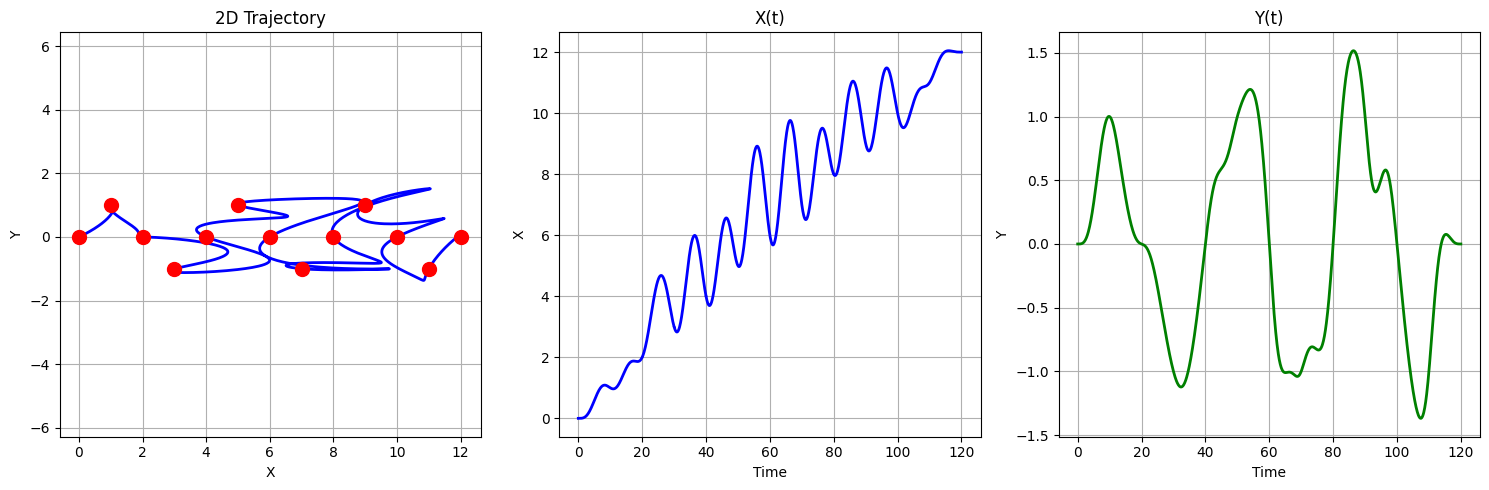

In [126]:
import matplotlib.pyplot as plt

def visualize_trajectory_2d(opt, Ts, checkpoints_x, checkpoints_y):
    """2D trajectory çiz"""

    # Her piece için trajectory hesapla
    t_all = []
    x_all = []
    y_all = []

    t_offset = 0
    for i in range(len(Ts)):
        T = Ts[i]
        t = np.linspace(0, T, 100)

        # x koordinatı
        d_x = opt.opt[0].dstar[2*opt.S*i : 2*opt.S*(i+1)]
        c_x = opt.opt[0].Abs[i] @ d_x
        x = np.polyval(c_x[::-1], t) # coefficient order

        # y koordinatı
        d_y = opt.opt[1].dstar[2*opt.S*i : 2*opt.S*(i+1)]
        c_y = opt.opt[1].Abs[i] @ d_y
        y = np.polyval(c_y[::-1], t)

        t_all.extend(t + t_offset)
        x_all.extend(x)
        y_all.extend(y)

        t_offset += T

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY plot
    axes[0].plot(x_all, y_all, 'b-', linewidth=2)
    axes[0].scatter(checkpoints_x, checkpoints_y, c='red', s=100, zorder=5)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_title('2D Trajectory')
    axes[0].axis('equal')
    axes[0].grid(True)

    # X vs t
    axes[1].plot(t_all, x_all, 'b-', linewidth=2)
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('X')
    axes[1].set_title('X(t)')
    axes[1].grid(True)

    # Y vs t
    axes[2].plot(t_all, y_all, 'g-', linewidth=2)
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Y')
    axes[2].set_title('Y(t)')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

visualize_trajectory_2d(opt,T,ww[0],ww[1])
